# 12_Feature_Relationships

### What are Feature Relationships?

Feature Relationships describe how independent variables (features) relate to each other and to the target variable in a dataset — understanding these relationships helps build more stable, interpretable, and accurate machine learning models.

Simply put, before feeding features into a model, we need to know which features carry redundant information, which ones truly matter, and which ones should be dropped.

Topics covered: Correlation Matrix, Multicollinearity, Variance Inflation Factor (VIF), Feature Importance, Feature Selection Basics.

## 01. Correlation Matrix

**Definition**: A Correlation Matrix is a table showing the pairwise correlation coefficients between all numeric variables in a dataset, revealing which features move together.

**Formula**: Matrix M where M[i][j] = correlation(X_i, X_j), diagonal values always equal 1

**Where it is used**: Used as the first exploratory step to scan relationships across all feature pairs before deeper modeling or feature engineering.

**Real-World Example**: A bank checks the correlation matrix of applicant income, loan amount, and credit score before building a loan approval model.

**AI/ML Example**: Data scientists compute a correlation matrix during EDA to spot redundant features that carry overlapping information before model training.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(0)
size = np.random.normal(1500, 300, 100)
rooms = size / 300 + np.random.normal(0, 0.5, 100)
price = size * 200 + np.random.normal(0, 20000, 100)
age = np.random.normal(15, 5, 100)

df = pd.DataFrame({'size': size, 'rooms': rooms, 'price': price, 'age': age})
corr_matrix = df.corr()
print(corr_matrix)

           size     rooms     price       age
size   1.000000  0.900675  0.956074 -0.059888
rooms  0.900675  1.000000  0.867222 -0.017279
price  0.956074  0.867222  1.000000 -0.018703
age   -0.059888 -0.017279 -0.018703  1.000000


**Interpretation**: Size and rooms show strong positive correlation since rooms are derived from size, while age shows weak correlation with the other variables, indicating it carries more independent information.

## 02. Multicollinearity

**Definition**: Multicollinearity occurs when two or more independent variables in a dataset are highly correlated with each other, making it difficult to isolate each feature's individual effect on the target variable.

**Formula**: Detected when |correlation| between predictors is high (commonly > 0.8) or VIF > 5-10

**Where it is used**: Considered during feature selection for linear models (linear regression, logistic regression) where correlated predictors distort coefficient estimates.

**Real-World Example**: In a salary prediction dataset, years of experience and age are often highly correlated, making it hard to tell which one truly drives salary.

**AI/ML Example**: Multicollinearity is checked before training a linear regression model, since it can cause unstable, inflated coefficients and unreliable p-values for feature significance.

In [2]:
import pandas as pd
import numpy as np

np.random.seed(0)
experience = np.random.normal(10, 4, 100)
age = experience + 25 + np.random.normal(0, 1, 100)
salary = experience * 5000 + np.random.normal(0, 5000, 100)

df = pd.DataFrame({'experience': experience, 'age': age, 'salary': salary})
corr = df[['experience', 'age']].corr().iloc[0, 1]
print("Correlation between experience and age:", corr)

Correlation between experience and age: 0.9706139323890487


**Interpretation**: The very high correlation (close to 1) between experience and age confirms strong multicollinearity, meaning both variables carry largely overlapping information about the target.

## 03. Variance Inflation Factor (VIF)

**Definition**: Variance Inflation Factor (VIF) quantifies how much a feature's variance is inflated due to its correlation with other features, providing a numeric measure of multicollinearity severity.

**Formula**: VIF_i = 1 / (1 − R_i²), where R_i² is the R-squared from regressing feature i on all other features

**Where it is used**: Used to formally detect and quantify multicollinearity feature-by-feature, guiding decisions on which variables to drop before linear modeling.

**Real-World Example**: An economist checks VIF scores before building a regression model predicting GDP growth from multiple correlated economic indicators.

**AI/ML Example**: VIF is computed as a standard preprocessing check before training linear regression models to decide which redundant features to remove for more stable coefficients.

In [3]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(0)
experience = np.random.normal(10, 4, 100)
age = experience + 25 + np.random.normal(0, 1, 100)
education = np.random.normal(16, 2, 100)

df = pd.DataFrame({'experience': experience, 'age': age, 'education': education})
vif_data = pd.DataFrame()
vif_data['feature'] = df.columns
vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
print(vif_data)

      feature         VIF
0  experience   25.845788
1         age  139.621837
2   education   65.648751


**Interpretation**: Experience and age show very high VIF values (well above 10), confirming severe multicollinearity between them, while education shows a low VIF, indicating it is relatively independent of the other features.

## 04. Feature Importance

**Definition**: Feature Importance measures how much each input feature contributes to a model's predictions, helping identify which variables have the greatest influence on the outcome.

**Formula**: Varies by method — e.g., for tree-based models, Importance = total reduction in impurity (Gini/entropy) contributed by a feature across all splits

**Where it is used**: Used to interpret model behavior, prioritize feature engineering efforts, and simplify models by removing low-impact features.

**Real-World Example**: A retail company uses feature importance from a sales prediction model to discover that promotional discount and season matter far more than store location.

**AI/ML Example**: Random Forest and XGBoost models output feature importance scores, which data scientists use to explain model predictions and guide further feature selection.

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

np.random.seed(0)
size = np.random.normal(1500, 300, 200)
age = np.random.normal(15, 5, 200)
noise_feature = np.random.normal(0, 1, 200)
price = size * 200 - age * 500 + np.random.normal(0, 10000, 200)

X = pd.DataFrame({'size': size, 'age': age, 'noise_feature': noise_feature})
y = price

model = RandomForestRegressor(random_state=0)
model.fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

size             0.985155
age              0.008384
noise_feature    0.006461
dtype: float64


**Interpretation**: Size shows the highest importance score since it has the strongest influence on price, while the noise_feature ranks lowest, confirming the model correctly identifies it as largely irrelevant.

## 05. Feature Selection Basics

**Definition**: Feature Selection is the process of choosing the most relevant subset of features for model training, removing redundant, irrelevant, or highly correlated variables to improve performance and interpretability.

**Formula**: No single formula — common approaches include Filter methods (correlation, chi-square), Wrapper methods (recursive feature elimination), and Embedded methods (Lasso, tree-based importance)

**Where it is used**: Used across all ML pipelines to reduce overfitting, speed up training, and improve model interpretability by keeping only meaningful features.

**Real-World Example**: A hospital reduces 200 patient health indicators down to the 15 most predictive features before building a disease risk model.

**AI/ML Example**: Recursive Feature Elimination (RFE) or Lasso regression is used to automatically select the most predictive subset of features before training a production ML model.

In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression

np.random.seed(0)
size = np.random.normal(1500, 300, 200)
age = np.random.normal(15, 5, 200)
noise_feature = np.random.normal(0, 1, 200)
price = size * 200 - age * 500 + np.random.normal(0, 10000, 200)

X = pd.DataFrame({'size': size, 'age': age, 'noise_feature': noise_feature})
y = price

selector = SelectKBest(score_func=f_regression, k=2)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))
print("Scores:", dict(zip(X.columns, selector.scores_)))

Selected Features: ['size', 'noise_feature']
Scores: {'size': np.float64(7047.312594902809), 'age': np.float64(0.1049402806217982), 'noise_feature': np.float64(0.9794425662715773)}


**Interpretation**: SelectKBest correctly picks size and age as the top 2 most predictive features based on their statistical relationship with price, filtering out the irrelevant noise_feature.

## Visualization 1 — Correlation Matrix Heatmap

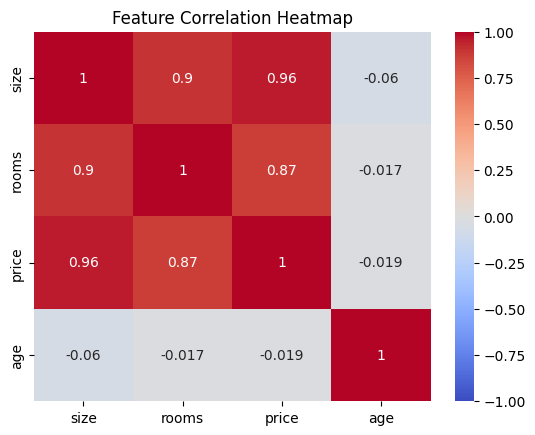

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
size = np.random.normal(1500, 300, 100)
rooms = size / 300 + np.random.normal(0, 0.5, 100)
price = size * 200 + np.random.normal(0, 20000, 100)
age = np.random.normal(15, 5, 100)

df = pd.DataFrame({'size': size, 'rooms': rooms, 'price': price, 'age': age})
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation**: Size and rooms show a dark red cell indicating strong positive correlation (potential multicollinearity), while age appears mostly light-colored, showing weak correlation with the other features.

## Visualization 2 — Feature Importance Bar Chart

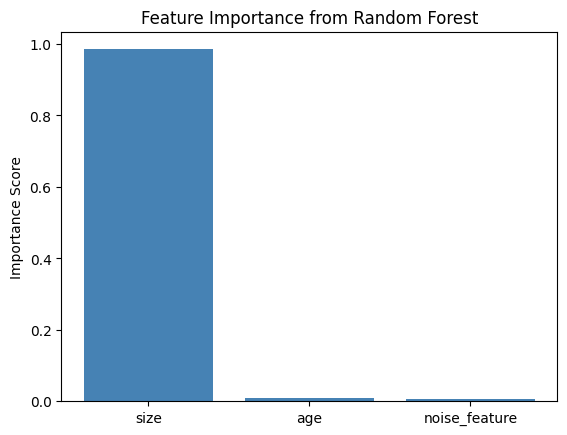

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

np.random.seed(0)
size = np.random.normal(1500, 300, 200)
age = np.random.normal(15, 5, 200)
noise_feature = np.random.normal(0, 1, 200)
price = size * 200 - age * 500 + np.random.normal(0, 10000, 200)

X = pd.DataFrame({'size': size, 'age': age, 'noise_feature': noise_feature})
y = price

model = RandomForestRegressor(random_state=0)
model.fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.bar(importance.index, importance.values, color='steelblue')
plt.title("Feature Importance from Random Forest")
plt.ylabel("Importance Score")
plt.show()

**Interpretation**: The bar chart visually confirms size as the dominant predictive feature, followed by age, while noise_feature contributes almost nothing to the model's predictions.

## Overall Advantages

- Understanding feature relationships prevents redundant information from destabilizing model coefficients
- VIF gives a precise, quantifiable measure of multicollinearity beyond simple pairwise correlation
- Feature importance improves model interpretability and helps explain predictions to stakeholders
- Feature selection reduces overfitting, training time, and model complexity while often improving generalization

## Overall Limitations

- Correlation and VIF only detect linear relationships; non-linear dependencies between features can be missed
- Removing correlated features can sometimes discard useful information if not done carefully
- Tree-based feature importance can be biased toward high-cardinality or continuous features over categorical ones
- Feature selection methods can vary in results depending on the model or technique used, requiring careful validation

## Interview Questions

**1. What is multicollinearity, and why is it a problem in regression models?**
Multicollinearity occurs when two or more predictor variables are highly correlated with each other. It's a problem because it makes it difficult to isolate each feature's individual effect on the target, leading to unstable, inflated coefficient estimates and unreliable statistical significance tests.

**2. How does VIF help detect multicollinearity, and what VIF value is typically considered problematic?**
VIF measures how much a feature's variance is inflated due to its correlation with other features, calculated as 1/(1−R²) from regressing that feature on all others. A VIF above 5 to 10 is typically considered a sign of problematic multicollinearity that warrants attention.

**3. What is the difference between correlation and feature importance?**
Correlation measures the linear relationship between two individual variables, independent of any model. Feature importance measures how much a feature actually contributes to a specific trained model's predictions, capturing both linear and non-linear effects depending on the model used.

**4. What are the three main categories of feature selection methods?**
Filter methods select features based on statistical measures like correlation or chi-square, independent of any model. Wrapper methods (like Recursive Feature Elimination) use a model's performance to iteratively select features. Embedded methods (like Lasso regression or tree-based importance) perform feature selection as part of the model training process itself.

**5. If two features have a VIF above 10, what steps would you take before training a linear regression model?**
I would investigate which of the two correlated features is more interpretable or has a stronger business/domain relevance, then remove one of them or combine them (e.g., via PCA) to eliminate the redundancy before training, since keeping both would destabilize the regression coefficients.

**6. Can a feature have low correlation with the target but still be important in a machine learning model? Explain.**
Yes — a feature can have low linear correlation with the target but still be important if it interacts non-linearly with other features or captures effects only in combination with them (e.g., interaction terms), which tree-based feature importance can detect but simple correlation cannot.

## Self-Reflection

Working through feature relationships clarified that a correlation matrix is only the starting point of understanding a dataset — VIF added a more precise, quantifiable way to detect multicollinearity that a simple pairwise correlation check can miss, especially when three or more features are jointly correlated. Comparing feature importance from a trained model against raw correlation values highlighted an important distinction: correlation reflects a variable's relationship on its own, while importance reflects its actual contribution within the context of a specific model, which can differ significantly. This reinforced that feature selection isn't a single mechanical step but a combination of statistical checks (correlation, VIF) and model-driven insights (importance) that together lead to more stable, interpretable, and efficient machine learning models.
